In [49]:
import polars as pl

ref_date = pl.read_parquet("../../data/iedb_meta/reference_date.parquet").with_columns(
    pl.col("article_date").str.to_date("%Y").alias("article_date")
)

iedb_II_conf = pl.read_parquet(
    "../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet"
)
iedb_II_tcrdock = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.af3_tcrdock.parquet"
)

iedb_II = iedb_II_conf.join(
    iedb_II_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)


iedb_II = iedb_II.explode("references").join(
    ref_date.select("reference_id", "article_date"),
    left_on="references",
    right_on="reference_id",
    how="left",
).filter(
    (pl.col("cognate") & pl.col("article_date").is_not_null()) | (~pl.col("cognate"))
)


iedb_I_conf = pl.read_parquet("../../data/iedb_I/triad/iedb_I_triad.conf_af3.parquet")
iedb_I = iedb_I_conf
iedb_I_tcrdock = pl.read_parquet(
    "../../data/iedb_I/triad/staged/iedb_I_triad.af3_tcrdock.parquet"
)

iedb_I = iedb_I_conf.join(
    iedb_I_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

iedb_I = iedb_I.explode("references").join(
    ref_date.select("reference_id", "article_date"),
    left_on="references",
    right_on="reference_id",
    how="left",
)

In [50]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import matplotlib.dates as mdates


def auc_by(
    df,
    featnames,
    mhc_class,
):
    grouping_cols = FORMAT_ANTIGEN_COLS + ["article_date"]
    antigen_st = df.filter(pl.col("cognate")).select(grouping_cols).unique()

    feat_df = []

    for row in antigen_st.iter_rows(named=True):

        focal_a_st = pl.DataFrame([row]).select(pl.exclude("job_name"))

        article_date = row["article_date"]
        if mhc_class == "I":
            hla = row["mhc_1_name"]
            antigen = row["mhc_1_name"] + "::" + row["peptide"]
        else:
            hla = row["mhc_2_name"]
            antigen = row["mhc_2_name"] + "::" + row["peptide"]

        focal_pos = df.join(focal_a_st, on=grouping_cols)
        focal_neg = df.join(
            focal_pos.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ).filter(~pl.col("cognate"))
        pos_triad = focal_pos.height

        focal_triad = pl.concat([focal_pos, focal_neg])

        for feat in featnames:
            dat = focal_triad.select(feat, "cognate").to_numpy()

            fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
            # roc_auc = abs(metrics.auc(fpr, tpr) - 0.5) + 0.5
            roc_auc = metrics.auc(fpr, tpr)

            feat_df.append(
                {
                    "auc": roc_auc,
                    # "fpr": list(fpr),
                    # "tpr": list(tpr),
                    "featname": feat,
                    "hla": hla,
                    "antigen": antigen,
                    # "ref": ref,
                    "pos_triad": pos_triad,
                    "article_date": article_date,
                }
            )

    feat_df = pl.DataFrame(feat_df)

    return feat_df


def plot_auc_vs_year(df: pl.DataFrame, title: str = ""):
    # Parse dates to pl.Date if needed
    if df.schema["article_date"] == pl.Utf8:
        df2 = df.with_columns(
            pl.col("article_date").str.strptime(pl.Date, strict=False)
        )
    elif df.schema["article_date"] == pl.Datetime:
        df2 = df.with_columns(pl.col("article_date").cast(pl.Date))
    else:
        df2 = df

    df2 = df2.select(["article_date", "auc"]).drop_nulls().sort("article_date")

    dates = df2.get_column("article_date").to_numpy()
    aucs = df2.get_column("auc").to_numpy()

    # Spearman correlation (convert dates to ordinal days)
    date_ord = dates.astype("datetime64[D]").astype(np.int64)
    rho, pval = spearmanr(date_ord, aucs)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(dates, aucs, s=28, alpha=0.8, edgecolors="k", linewidths=0.3)

    # Nice date axis
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    # Annotate Spearman
    ax.text(
        0.02,
        0.98,
        f"Spearman r = {rho:.3f}, p = {pval:.3g}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.25),
    )

    ax.set_xlabel("Article date")
    ax.set_ylabel("AUC")
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig, ax

In [51]:
feats = [
    # "iptm",
    "mean_p_tcr_pae",
]

auc_partition_II = auc_by(
    iedb_II.with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    feats,
    "II",
)
auc_partition_I = auc_by(
    iedb_I.with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    feats,
    "I",
)

In [55]:
auc_partition_II.select(pl.col("auc").median())

auc
f64
0.754183


In [56]:
auc_partition_I.select(pl.col("auc").median())

auc
f64
0.669967


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'AUC vs. Num Positive Triads by Assay Type by Antigen-study (II)'}, xlabel='Article date', ylabel='AUC'>)

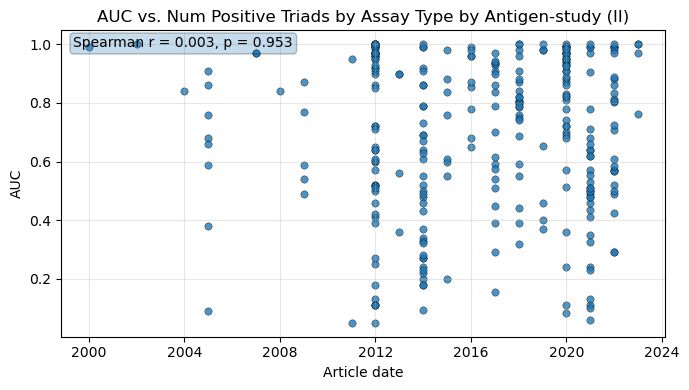

In [53]:
plot_auc_vs_year(
    auc_partition_II,
    title="AUC vs. Num Positive Triads by Assay Type by Antigen-study (II)",
)

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'AUC vs. Num Positive Triads by Assay Type by Antigen-study (I)'}, xlabel='Article date', ylabel='AUC'>)

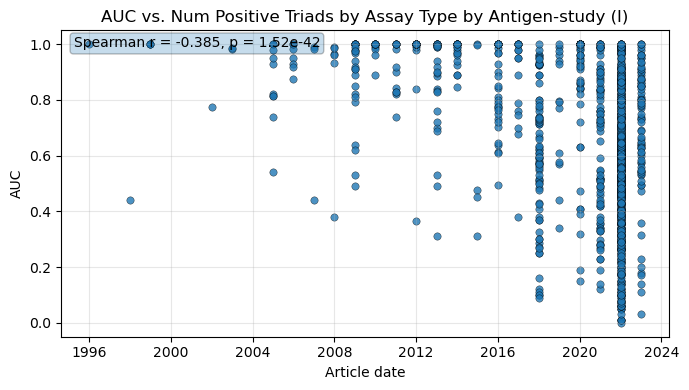

In [54]:
plot_auc_vs_year(
    auc_partition_I,
    title="AUC vs. Num Positive Triads by Assay Type by Antigen-study (I)",
)